<a href="https://colab.research.google.com/github/janane-jaipratha/BUILD-AND-DEPLOYMENT-OF-MACHINE-LEARNING/blob/main/241501072_exp_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10, Loss: 0.0831
Epoch 2/10, Loss: 0.0391
Epoch 3/10, Loss: 0.0278
Epoch 4/10, Loss: 0.0209
Epoch 5/10, Loss: 0.0162
Epoch 6/10, Loss: 0.0127
Epoch 7/10, Loss: 0.0102
Epoch 8/10, Loss: 0.0078
Epoch 9/10, Loss: 0.0063
Epoch 10/10, Loss: 0.0050


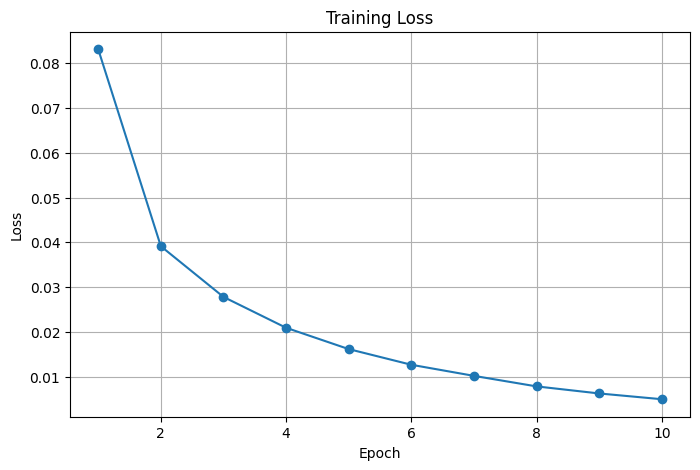

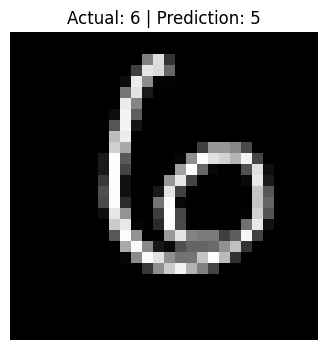

In [1]:
# Step 1: Import Necessary Libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.preprocessing import OneHotEncoder


# Step 2: Load and Preprocess the Dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values and reshape images
X_train = X_train.reshape(-1, 784).astype(np.float32) / 255.0
X_test = X_test.reshape(-1, 784).astype(np.float32) / 255.0

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y_train = encoder.fit_transform(y_train.reshape(-1, 1))
y_test = encoder.transform(y_test.reshape(-1, 1))


# Step 3: Initialize the Network
input_size = 784
hidden_size = 64
output_size = 10

np.random.seed(42)

W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))


# Step 4: Define Activation and Loss Functions
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))


def sigmoid_deriv(x):
    return x * (1 - x)


def loss_fn(y, y_hat):
    return -np.mean(
        y * np.log(y_hat + 1e-8) +
        (1 - y) * np.log(1 - y_hat + 1e-8)
    )


# Step 5: Train the Model
epochs = 10
lr = 0.1

losses = []

# Using a smaller subset makes manual training much faster
X_train_small = X_train[:10000]
y_train_small = y_train[:10000]

for epoch in range(epochs):

    total_loss = 0

    for i in range(X_train_small.shape[0]):

        # Get one sample
        x = X_train_small[i:i+1]
        y = y_train_small[i:i+1]

        # -------- Forward Propagation --------
        z1 = x @ W1 + b1
        a1 = sigmoid(z1)

        z2 = a1 @ W2 + b2
        a2 = sigmoid(z2)

        # -------- Calculate Loss --------
        loss = loss_fn(y, a2)
        total_loss += loss

        # -------- Backpropagation --------
        dz2 = a2 - y
        dW2 = a1.T @ dz2
        db2 = dz2

        dz1 = (dz2 @ W2.T) * sigmoid_deriv(a1)
        dW1 = x.T @ dz1
        db1 = dz1

        # -------- Update Weights --------
        W2 -= lr * dW2
        b2 -= lr * db2

        W1 -= lr * dW1
        b1 -= lr * db1

    avg_loss = total_loss / X_train_small.shape[0]
    losses.append(avg_loss)

    print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")


# Step 6: Visualize Training Loss
plt.figure(figsize=(8, 5))

plt.plot(range(1, epochs + 1), losses, marker='o')

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.show()


# Step 7: Predict a Sample Digit
def predict(img):

    # Reshape image
    img = img.reshape(1, 784).astype(np.float32) / 255.0

    # Forward propagation
    z1 = img @ W1 + b1
    a1 = sigmoid(z1)

    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)

    # Return class with highest probability
    return np.argmax(a2)


# Select a test image
idx = 100

prediction = predict(X_test[idx])

# Display image
plt.figure(figsize=(4, 4))

plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')

plt.title(
    f"Actual: {np.argmax(y_test[idx])} | Prediction: {prediction}"
)

plt.axis('off')
plt.show()